Using device: cpu


100%|██████████| 170M/170M [00:42<00:00, 4.04MB/s]


Epoch 1: Loss = 1.7063, Accuracy = 39.99%
Epoch 2: Loss = 1.4895, Accuracy = 48.07%
Epoch 3: Loss = 1.3898, Accuracy = 51.54%
Epoch 4: Loss = 1.3138, Accuracy = 54.24%
Epoch 5: Loss = 1.2577, Accuracy = 56.19%
Epoch 6: Loss = 1.2063, Accuracy = 58.20%
Epoch 7: Loss = 1.1611, Accuracy = 59.68%
Epoch 8: Loss = 1.1194, Accuracy = 61.25%
Epoch 9: Loss = 1.0841, Accuracy = 62.50%
Epoch 10: Loss = 1.0442, Accuracy = 63.77%
Epoch 1: Loss = 1.6355, Accuracy = 42.72%
Epoch 2: Loss = 1.4316, Accuracy = 50.07%
Epoch 3: Loss = 1.3458, Accuracy = 53.13%
Epoch 4: Loss = 1.2785, Accuracy = 55.48%
Epoch 5: Loss = 1.2135, Accuracy = 57.72%
Epoch 6: Loss = 1.1594, Accuracy = 59.94%
Epoch 7: Loss = 1.1085, Accuracy = 61.70%
Epoch 8: Loss = 1.0653, Accuracy = 63.02%
Epoch 9: Loss = 1.0265, Accuracy = 64.59%
Epoch 10: Loss = 0.9686, Accuracy = 66.74%


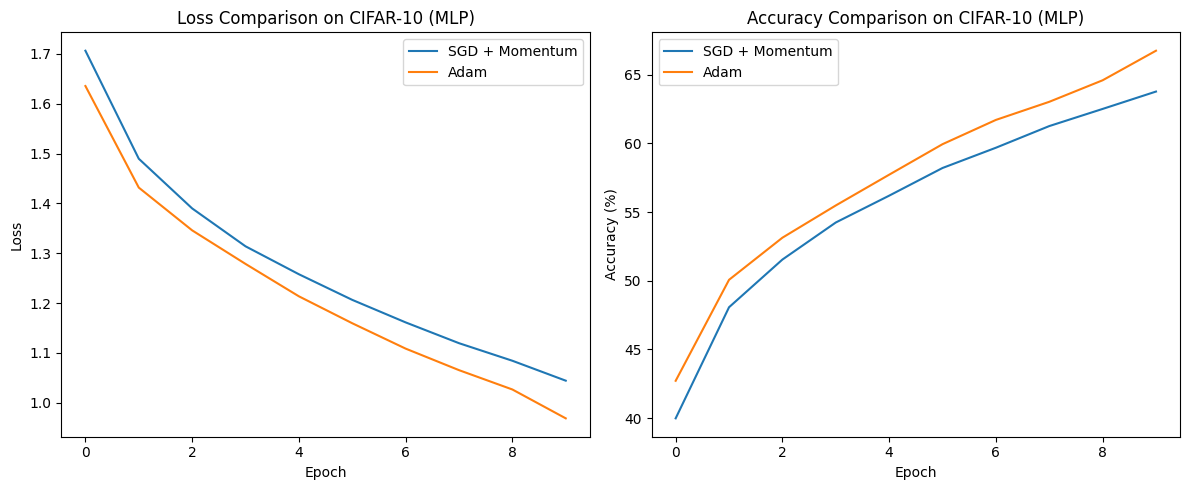

In [ ]:
# Step 1: Import Necessary Libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


# Step 2: Set Device and Load Dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True
)


# Step 3: Define MLP Model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.net = nn.Sequential(
            nn.Linear(3 * 32 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


# Step 4: Define Training Function
def train(model, optimizer, epochs=10):
    model.to(device)

    loss_fn = nn.CrossEntropyLoss()

    losses = []
    accuracies = []

    for epoch in range(epochs):

        total_loss = 0
        correct = 0
        total = 0

        model.train()

        for imgs, labels in trainloader:

            imgs, labels = imgs.to(device), labels.to(device)

            # Forward pass
            outputs = model(imgs)

            # Calculate loss
            loss = loss_fn(outputs, labels)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Calculate loss and accuracy
            total_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Average loss and accuracy
        avg_loss = total_loss / len(trainloader)
        accuracy = 100.0 * correct / total

        losses.append(avg_loss)
        accuracies.append(accuracy)

        print(
            f"Epoch {epoch + 1}: "
            f"Loss = {avg_loss:.4f}, "
            f"Accuracy = {accuracy:.2f}%"
        )

    return losses, accuracies


# Step 5: Train with SGD + Momentum
model_sgd = MLP()

sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.01,
    momentum=0.9
)

losses_sgd, acc_sgd = train(
    model_sgd,
    sgd
)


# Step 5: Train with Adam
model_adam = MLP()

adam = optim.Adam(
    model_adam.parameters(),
    lr=0.001
)

losses_adam, acc_adam = train(
    model_adam,
    adam
)


# Step 6: Visualize Loss and Accuracy Comparison
plt.figure(figsize=(12, 5))


# Loss Comparison
plt.subplot(1, 2, 1)

plt.plot(
    losses_sgd,
    label="SGD + Momentum"
)

plt.plot(
    losses_adam,
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison on CIFAR-10 (MLP)")
plt.legend()


# Accuracy Comparison
plt.subplot(1, 2, 2)

plt.plot(
    acc_sgd,
    label="SGD + Momentum"
)

plt.plot(
    acc_adam,
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison on CIFAR-10 (MLP)")
plt.legend()


plt.tight_layout()
plt.show()